- Aqui, terá a importação dos dados, o split temporal, e o estabelecimento do baseline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             roc_auc_score, log_loss, brier_score_loss)
from sklearn.model_selection import learning_curve, TimeSeriesSplit

# carga da base de dados gerada no encerramento da engenharia de atributos
df = pd.read_parquet('../etl/processed_data/df_features_modelagem.parquet')

# isolamento dos diferenciais liquidos e atributos contextuais
cols_features = [c for c in df.columns if c.startswith('diff_')] + ['div_game', 'vantagem_descanso']
col_target = 'target_home_win'

# divisao temporal estrita respeitando a ordem cronologica das temporadas
# conjunto de treino utilizando as temporadas de 2021 a 2024
mask_train = df['season'].between(2021, 2024)
X_train, y_train = df[mask_train][cols_features], df[mask_train][col_target]

# conjunto de teste e avaliacao utilizando a temporada de 2025
mask_val = df['season'] == 2025
X_val, y_val = df[mask_val][cols_features], df[mask_val][col_target]

print(f"dimensoes de treino (2021 a 2024): {X_train.shape}")
print(f"dimensoes de teste (2025): {X_val.shape}")

dimensoes de treino (2021 a 2024): (1139, 30)
dimensoes de teste (2025): (285, 30)


In [3]:
# funcao modular para calculo de metricas rigidas e probabilisticas
def avaliar_modelo(model, X_tr, y_tr, X_te, y_te, nome_modelo):
    model.fit(X_tr, y_tr)
    
    # obtencao de rotulos discretos e probabilidades da classe positiva
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    # apuracao de metricas de classificacao rigida
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    
    # apuracao de metricas probabilisticas e discriminacao
    roc_auc = roc_auc_score(y_te, y_proba)
    brier = brier_score_loss(y_te, y_proba)
    logloss = log_loss(y_te, y_proba)
    
    print(f"--- desempenho do baseline: {nome_modelo} ---")
    print(f"acuracia:  {acc:.4f} | roc-auc: {roc_auc:.4f}")
    print(f"precisao:  {prec:.4f} | recall:  {rec:.4f}")
    print(f"brier:     {brier:.4f} | log loss:{logloss:.4f}\n")
    
    return model

In [4]:
# inspeciona a lista completa de features selecionadas para o treinamento
print(f"total de preditores selecionados: {len(cols_features)}")
print("\ncolunas situacionais e de instabilidade capturadas:")
print([c for c in cols_features if any(k in c for k in ['qb', 'line', 'bye', 'descanso', 'div'])])

total de preditores selecionados: 30

colunas situacionais e de instabilidade capturadas:
['diff_def_qb_hits_last3', 'diff_def_qb_hits_season', 'diff_is_backup_qb', 'diff_o_line_out', 'div_game', 'vantagem_descanso']


In [5]:
# execucao do baseline treinando em 2021 a 2024 e testando em 2025
xgb_base = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)
xgb_base = avaliar_modelo(xgb_base, X_train, y_train, X_val, y_val, "xgboost default")

--- desempenho do baseline: xgboost default ---
acuracia:  0.6561 | roc-auc: 0.6794
precisao:  0.6687 | recall:  0.7039
brier:     0.2597 | log loss:0.8206



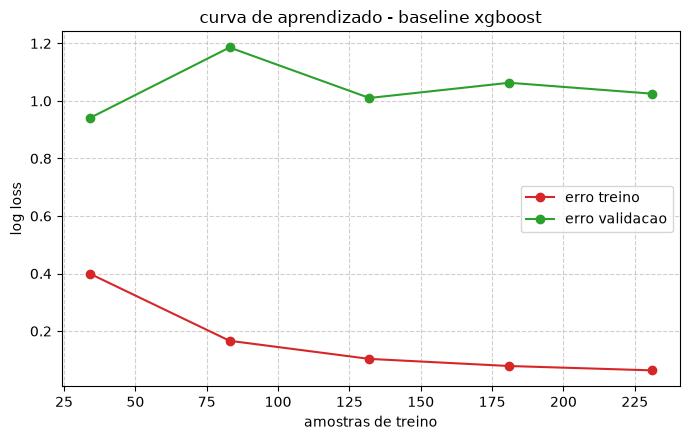

In [6]:
# funcao para plotar a curva de aprendizado usando perda logistica
def plot_learning_curve(estimator, title, x_data, y_data, cv=None):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, x_data, y_data, cv=cv, scoring='neg_log_loss',
        train_sizes=np.linspace(0.15, 1.0, 5), n_jobs=-1
    )
    
    # inversao do score negativo para escala padrao de log loss
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(7, 4.5))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="tab:red", label="erro treino")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="tab:green", label="erro validacao")
    
    plt.title(title)
    plt.xlabel("amostras de treino")
    plt.ylabel("log loss")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# execucao da curva temporal com janelas progressivas em 2021 a 2024
tscv = TimeSeriesSplit(n_splits=4)
plot_learning_curve(xgb_base, "curva de aprendizado - baseline xgboost", X_train, y_train, cv=tscv)

- Overfitting severo pode ser observado, apesar de as métricas parecerem bastante boas, pra um modelo sem otimização nenhuma, tanto nas features quanto nos hiperparametros.